# 07 - Avaliação Temporal e de Negócio

Já tenho o modelo (XGBoost, notebook 06). Aqui olho para ele de outros ângulos:

- o desempenho se mantém ao longo dos meses do teste?
- funciona parecido nos diferentes segmentos de reserva?
- as linhas repetidas que decidi manter no notebook 03 mudam alguma conclusão?
- como escolher o limiar pensando no uso pelo hotel?

Também mostro uma medida de exposição das reservas de risco, deixando claro
que é um indicador aproximado, não uma estimativa de perda em dinheiro.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier

from src.preprocessing import (preparar, separar_treino_teste,
                               VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

LIMIAR = 0.40   # escolhido no notebook 06

In [2]:
df = preparar()
treino, teste = separar_treino_teste(df)
variaveis = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS

preproc = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     VARIAVEIS_CATEGORICAS),
])

peso_pos = (treino[ALVO] == 0).sum() / (treino[ALVO] == 1).sum()
modelo = Pipeline([
    ("prep", preproc),
    ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.9,
                          scale_pos_weight=peso_pos, eval_metric="logloss",
                          random_state=42, n_jobs=4)),
])
modelo.fit(treino[variaveis], treino[ALVO])

teste = teste.copy()
teste["prob"] = modelo.predict_proba(teste[variaveis])[:, 1]
teste["alerta"] = (teste["prob"] >= LIMIAR).astype(int)

print("ROC-AUC teste:", round(roc_auc_score(teste[ALVO], teste["prob"]), 3),
      " PR-AUC teste:", round(average_precision_score(teste[ALVO], teste["prob"]), 3))

ROC-AUC teste: 0.889  PR-AUC teste: 0.847


In [3]:
def metricas_grupo(g):
    prob, y = g["prob"], g[ALVO]
    pred = (prob >= LIMIAR).astype(int)
    return pd.Series({
        "reservas": len(g),
        "taxa_cancel": y.mean(),
        "recall": recall_score(y, pred, zero_division=0),
        "precision": precision_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, prob) if y.nunique() == 2 else np.nan,
        "pr_auc": average_precision_score(y, prob) if y.nunique() == 2 else np.nan,
    })

## 2. Desempenho ao longo do tempo

In [4]:
teste["mes"] = teste["arrival_date"].dt.to_period("M").astype(str)
por_mes = teste.groupby("mes").apply(metricas_grupo).round(3)
por_mes

,reservas,taxa_cancel,recall,precision,roc_auc,pr_auc
mes,,,,,,
2017-04,1665.000,0.446,0.903,0.788,0.935,0.923
2017-05,6305.000,0.438,0.805,0.789,0.915,0.898
2017-06,5639.000,0.432,0.768,0.774,0.897,0.874
2017-07,5310.000,0.374,0.718,0.703,0.859,0.758
2017-08,4923.000,0.368,0.767,0.633,0.848,0.742


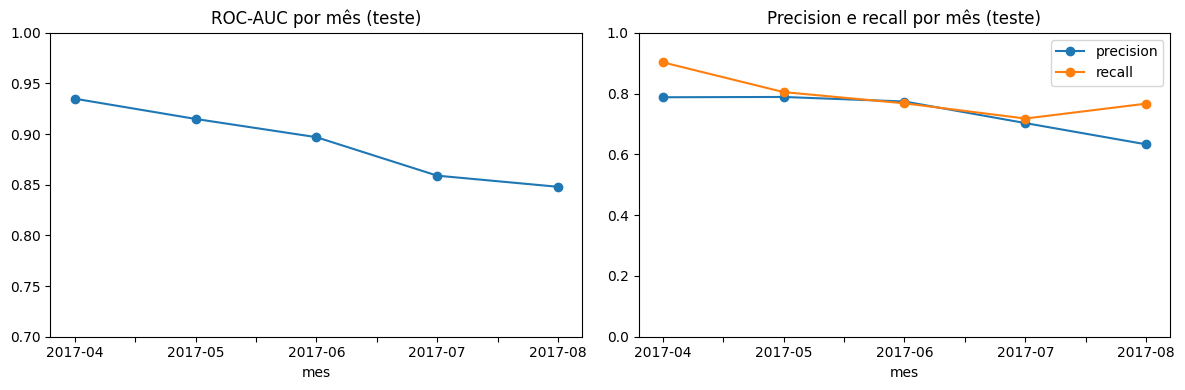

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
por_mes["roc_auc"].plot(marker="o", ax=ax[0], title="ROC-AUC por mês (teste)")
ax[0].set_ylim(0.7, 1.0)
por_mes[["precision", "recall"]].plot(marker="o", ax=ax[1], title="Precision e recall por mês (teste)")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

O ROC-AUC cai um pouco nos últimos meses do teste, mas nenhum mês fica perto
do acaso. Precision e recall acompanham a variação da taxa de cancelamento de
cada mês. O padrão sugere re-treinar o modelo periodicamente, e não deixá-lo
fixo por muito tempo.

## 3. Desempenho por segmento

In [6]:
for coluna in ["hotel", "deposit_type", "market_segment", "customer_type"]:
    tab = teste.groupby(coluna).apply(metricas_grupo)
    tab = tab[tab["reservas"] >= 100].round(3)
    print(coluna)
    print(tab)
    print()

hotel
              reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
hotel                                                                  
City Hotel   16363.000        0.432   0.820      0.725    0.886   0.863
Resort Hotel  7479.000        0.357   0.668      0.771    0.909   0.828

deposit_type
              reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
deposit_type                                                           
No Deposit   21528.000        0.345   0.710      0.659    0.854   0.709
Non Refund    2292.000        1.000   1.000      1.000    1.000   1.000



market_segment
                reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
market_segment                                                           
Complementary    105.000        0.143   0.200      0.375    0.686   0.264
Corporate        640.000        0.242   0.832      0.705    0.930   0.853
Direct          2645.000        0.183   0.400      0.500    0.794   0.489
Groups          2686.000        0.671   0.994      0.932    0.996   0.998
Offline TA/TO   3778.000        0.344   0.958      0.863    0.985   0.972
Online TA      13916.000        0.429   0.705      0.662    0.799   0.711

customer_type
                 reservas  taxa_cancel  recall  precision  roc_auc  pr_auc
customer_type                                                             
Contract          526.000        0.127   0.970      0.915    0.996   0.979
Group             116.000        0.103   0.833      0.625    0.972   0.821
Transient       20140.000        0.454   0.772      0.746    0.871   0.852
Tra

O modelo separa bem os dois tipos de hotel. Em `deposit_type = Non Refund`
quase toda reserva cancela e o acerto é fácil. O segmento com separação mais
fraca costuma ser o `Direct`, que tem cancelamento baixo e comportamento
menos previsível. Fora esses casos, nenhum segmento grande fica perto do acaso.

## 4. Sensibilidade às linhas repetidas

In [7]:
cols = [c for c in treino.columns if c not in ["arrival_date", "booking_date"]]
treino_sem_rep = treino.drop_duplicates(subset=cols)
print("treino:", len(treino), " sem repetições:", len(treino_sem_rep))

modelo_sr = Pipeline([
    ("prep", preproc),
    ("xgb", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5, subsample=0.9,
                          scale_pos_weight=peso_pos, eval_metric="logloss",
                          random_state=42, n_jobs=4)),
])
modelo_sr.fit(treino_sem_rep[variaveis], treino_sem_rep[ALVO])
prob_sr = modelo_sr.predict_proba(teste[variaveis])[:, 1]

pd.DataFrame({
    "com repetições": [roc_auc_score(teste[ALVO], teste["prob"]),
                       average_precision_score(teste[ALVO], teste["prob"])],
    "sem repetições": [roc_auc_score(teste[ALVO], prob_sr),
                       average_precision_score(teste[ALVO], prob_sr)],
}, index=["ROC-AUC", "PR-AUC"]).round(3)

treino: 95367  sem repetições: 66468


,com repetições,sem repetições
ROC-AUC,0.889,0.886
PR-AUC,0.847,0.845


As métricas de ordenação ficam praticamente iguais. Remover as linhas
repetidas do treino não melhora nem piora o resultado no teste. Isso reforça
a decisão do notebook 03 de mantê-las: sem um identificador de reserva não há
razão forte para removê-las, e elas não distorcem o modelo.

## 5. Escolha do limiar pelo lado do negócio

In [8]:
n_canc = int(teste[ALVO].sum())
linhas = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (teste["prob"] >= t).astype(int)
    rec = recall_score(teste[ALVO], pred)
    linhas.append({"limiar": t,
                   "alertas": int(pred.sum()),
                   "precision": round(precision_score(teste[ALVO], pred), 3),
                   "recall": round(rec, 3),
                   "cancelamentos_capturados": int(round(rec * n_canc)),
                   "cancelamentos_perdidos": n_canc - int(round(rec * n_canc))})
pd.DataFrame(linhas)

,limiar,alertas,precision,recall,cancelamentos_capturados,cancelamentos_perdidos
0,0.200,15036,0.616,0.951,9263,478
1,0.300,12623,0.678,0.878,8553,1188
2,0.400,10315,0.735,0.778,7582,2159
3,0.500,8658,0.784,0.697,6791,2950
4,0.600,7689,0.811,0.640,6233,3508


Não dá para dizer qual limiar é "o melhor" sem saber quanto vale para o hotel
cada alerta e cada cancelamento não previsto. Com um limiar mais baixo o
hotel cobre mais cancelamentos mas recebe mais alertas; com um limiar mais
alto, o contrário. Mantenho o limiar do notebook 06 como padrão e deixo essa
tabela como apoio.

## 6. Exposição potencial das reservas de risco

In [9]:
teste["exposicao"] = teste["prob"] * teste["adr"] * teste["total_nights"]
resumo = (teste[teste["alerta"] == 1]
          .groupby("hotel")
          .agg(reservas_risco=("alerta", "size"),
               exposicao_total=("exposicao", "sum"),
               exposicao_media=("exposicao", "mean")))
resumo.round(0)

,reservas_risco,exposicao_total,exposicao_media
hotel,,,
City Hotel,8003,2654799.000,332.000
Resort Hotel,2312,1394976.000,603.000


Isso **não** é uma estimativa de perda. É um indicador de exposição:
reservas mais caras, mais longas e com risco mais alto pesam mais. Serve para
priorizar o acompanhamento, não para dizer quanto o hotel deixaria de ganhar.

## 7. O que levo para o próximo notebook

- o modelo se mantém estável ao longo dos meses do teste, com uma leve queda
  no fim que sugere re-treino periódico;
- funciona de forma parecida nos principais segmentos;
- manter ou remover as linhas repetidas quase não muda o resultado;
- a escolha do limiar foi apresentada como uma decisão do hotel, com uma
  tabela de apoio.

No notebook 08 abro o modelo: quais variáveis pesam mais e onde ele erra.